# Imports

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import segmentation_models_pytorch as smp
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pytorch_msssim import MS_SSIM
from tqdm import tqdm
import timm
import lpips
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchmetrics.image import PeakSignalNoiseRatio, MultiScaleStructuralSimilarityIndexMeasure
import torch.backends.cuda as cuda_backends
from torch.nn.utils import spectral_norm
from pytorch_msssim import ms_ssim
import random
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device("cuda")  # Set device to GPU
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")  # Fallback to CPU
    print("CUDA is not available. Using CPU.")

Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU


# Transforms

In [2]:
input_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

target_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# Dataset

In [3]:
class PairedDataset(Dataset):
    """
    Loads paired LQ / HQ images from two folders.
    Assumes filenames are identical in both folders.
 
    data/
      low_quality/    1.png  2.png  ...
      high_quality/   1.png  2.png  ...
    """
    def __init__(self, lq_dir, hq_dir,
                 input_transform=None,
                 target_transform=None,
                augment=False):
 
        self.lq_dir           = lq_dir
        self.hq_dir           = hq_dir
        self.input_transform  = input_transform
        self.target_transform = target_transform
        self.augment          = augment
 
        # Sort so index i always gives the same pair
        self.filenames = sorted(os.listdir(lq_dir))
 
    def __len__(self):
        return len(self.filenames)
 
    def __getitem__(self, idx):
        fname = self.filenames[idx]
 
        lq_img = Image.open(os.path.join(self.lq_dir, fname)).convert("L")
        hq_img = Image.open(os.path.join(self.hq_dir, fname)).convert("L")
 
        if self.input_transform:
            lq_img = self.input_transform(lq_img)
 
        if self.target_transform:
            hq_img = self.target_transform(hq_img)

        if self.augment:
            if random.random() > 0.5:
                lq_img = TF.hflip(lq_img)
                hq_img = TF.hflip(hq_img)
            
            if random.random() > 0.5:
                lq_img = TF.vflip(lq_img)
                hq_img = TF.vflip(hq_img)

            # Random rotation
            if random.random() > 0.5:
                angle = random.uniform(-10, 10)
                lq_img = TF.rotate(lq_img, angle)
                hq_img = TF.rotate(hq_img, angle)
            
            # Random crop and resize
            if random.random() > 0.5:
                i, j, h, w = transforms.RandomCrop.get_params(lq_img, output_size=(220, 220))
                lq_img = TF.resize(TF.crop(lq_img, i, j, h, w), (256, 256))
                hq_img = TF.resize(TF.crop(hq_img, i, j, h, w), (256, 256))

            if random.random() > 0.5:
                noise = torch.randn_like(lq_img) * 0.02
                lq_img = (lq_img + noise).clamp(0, 1)
            if random.random() > 0.5:
                factor = random.uniform(0.8, 1.2)
                lq_img = TF.adjust_brightness(lq_img, factor)
     
        return lq_img, hq_img

In [4]:
lq_dir        = "train_dataset/low_quality"
hq_dir        = "train_dataset/high_quality"

In [5]:
train_dataset = PairedDataset(lq_dir, hq_dir,
    input_transform=input_transform,
    target_transform=target_transform,
    augment=True)

val_dataset = PairedDataset(lq_dir, hq_dir,
    input_transform=input_transform,
    target_transform=target_transform,
    augment=False)

val_split=0.1
# ── Reproducible split indices ──
total      = len(train_dataset)
val_size   = int(total * val_split)
train_size = total - val_size

indices = torch.randperm(total, generator=torch.Generator().manual_seed(42)).tolist()

train_dataset = torch.utils.data.Subset(train_dataset, indices[:train_size])
val_dataset   = torch.utils.data.Subset(val_dataset,   indices[train_size:])

In [6]:
# ── DataLoaders ──
batch_size    = 8

train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=True
    )
val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True
    )

# Loss

In [7]:
def l1_loss(x,x_recon):
    l1 = F.l1_loss(x_recon, x, reduction='mean')
    return l1

In [8]:
def fm_loss(real_feats, fake_feats):
    loss = 0
    for rf, ff in zip(real_feats, fake_feats):
        loss += torch.mean(torch.abs(rf.detach() - ff))
    return loss

In [9]:
def rp_gan_loss_D(real_logits, fake_logits):
    fake_mean = fake_logits.detach().mean()
    real_mean = real_logits.detach().mean()
    real_loss = F.softplus(-(real_logits - fake_mean))
    fake_loss = F.softplus( fake_logits - real_mean)
    return real_loss.mean() + fake_loss.mean()

def rp_gan_loss_G(real_logits, fake_logits):
    fake_mean = fake_logits.detach().mean()
    real_mean = real_logits.detach().mean()
    real_loss = F.softplus( real_logits - fake_mean)
    fake_loss = F.softplus(-(fake_logits - real_mean))
    return real_loss.mean() + fake_loss.mean()

In [10]:
def gradient_penalty(d_out, x, gamma=1.0):
    grads = torch.autograd.grad(
        outputs=d_out.mean(),
        inputs=x,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    grad_norm_sq = grads.reshape(grads.size(0), -1).pow(2).sum(1)
    
    return (gamma / 2) * grad_norm_sq.mean()

In [11]:
def lpips_loss(hq, fake, loss_fn):
    fake_3ch = fake.repeat(1, 3, 1, 1) * 2 - 1   # [0,1] → [-1,1]
    hq_3ch   = hq.repeat(1, 3, 1, 1)   * 2 - 1
    return loss_fn(fake_3ch, hq_3ch).mean()

# Metrics

In [12]:
psnr_metric     = PeakSignalNoiseRatio(data_range=1.0).to(device)
msssim_metric   = MultiScaleStructuralSimilarityIndexMeasure(data_range=1.0).to(device)

# Model

In [13]:
gen_model = smp.UnetPlusPlus(
        encoder_name="resnext50_32x4d",
        encoder_weights="ssl",
        in_channels=1,
        classes=1,
        activation='sigmoid'      
    )


# Change to Bi-Linear Interpolation
for block in gen_model.decoder.blocks.values():
    block.interpolation_mode = "bilinear"
gen_model.to(device)

UnetPlusPlus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsa

In [14]:
class PatchDiscriminator(nn.Module):
    def __init__(self, input_dim=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(input_dim, 64, 4, stride=2, padding=1),
                nn.LeakyReLU(0.2)
            ),
            nn.Sequential(
                nn.Conv2d(64, 128, 4, stride=2, padding=1),
                nn.InstanceNorm2d(128),
                nn.LeakyReLU(0.2)
            ),
            nn.Sequential(
                nn.Conv2d(128, 256, 4, stride=2, padding=1),
                nn.InstanceNorm2d(256),
                nn.LeakyReLU(0.2)
            ),
            nn.Sequential(
                nn.Conv2d(256, 512, 4, stride=1, padding=1),
                nn.InstanceNorm2d(512),
                nn.LeakyReLU(0.2)
            ),
            nn.Conv2d(512, 1, 4, padding=1),  # output — not a block, no activation
        ])

    def forward(self, lq, target, return_feats=False):
        x = torch.cat([lq, target], dim=1)
        feats = []
        for i, block in enumerate(self.blocks):
            x = block(x)
            if return_feats and i < len(self.blocks) - 1:  # skip output layer
                feats.append(x)
        return (x, feats) if return_feats else x

In [15]:
D_model = PatchDiscriminator()
D_model.to(device)

PatchDiscriminator(
  (blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(2, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.2)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (3): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
      (1): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (4): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  )
)

In [16]:
# Learnable log-variances (log scale for numerical stability)
# log_var_adv = nn.Parameter(torch.tensor([0.0], device=device))
log_var_l1  = nn.Parameter(torch.tensor([0.0],  device=device))
log_var_fm  = nn.Parameter(torch.tensor([0.0], device=device))
log_var_ms  = nn.Parameter(torch.tensor([0.0], device=device))
log_var_lpips = nn.Parameter(torch.tensor([0.0], device=device))

# gen_optimizer = optim.AdamW([
#     {'params': gen_model.parameters()},
#     {'params': [log_var_adv, log_var_l1, log_var_fm, log_var_ms], 'lr': 1e-4}
# ], lr=1e-4)

gen_optimizer = optim.AdamW([
    {'params': gen_model.parameters()},
    {'params': [log_var_l1, log_var_fm, log_var_ms, log_var_lpips], 'lr': 1e-4}
], lr=1e-4)
D_optimizer = optim.AdamW(D_model.parameters(), lr=1e-4*0.3)

# Training & Val

In [17]:
loss_fn_lpips = lpips.LPIPS(net='vgg').to(device)

# Freeze it — you don't want gradients flowing through VGG
for param in loss_fn_lpips.parameters():
    param.requires_grad = False

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


C:\Users\david\anaconda3\envs\DL\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\david\anaconda3\envs\DL\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: C:\Users\david\anaconda3\envs\DL\Lib\site-packages\lpips\weights\v0.1\vgg.pth


C:\Users\david\anaconda3\envs\DL\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_location

In [18]:
num_epochs = 100
gen_scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(gen_optimizer, T_0=25, T_mult=2, eta_min=1e-6)
D_scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(D_optimizer, T_0=25, T_mult=2, eta_min=3e-7) #1e-6 * 0.3

In [19]:
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)

patience = 35  # stop if no improvement for 20 epochs
no_improve = 0

best_val_msssim = 0.0

# ── Estimate initial loss scales ──
gen_model.eval()
D_model.eval()

# scale_adv, scale_l1, scale_fm, scale_ms = 0, 0, 0, 0
scale_adv, scale_l1, scale_fm, scale_ms, scale_lpips = 0, 0, 0, 0, 0
n_batches = 10

with torch.no_grad():
    for i, (lq, hq) in enumerate(train_loader):
        if i >= n_batches: break
        lq, hq = lq.to(device), hq.to(device)

        fake = gen_model(lq)
        real_out, real_feats = D_model(lq, hq, return_feats=True)
        fake_out, fake_feats = D_model(lq, fake, return_feats=True)

        scale_adv += rp_gan_loss_G(real_out, fake_out).item()
        scale_l1  += l1_loss(hq, fake).item()
        scale_fm  += fm_loss(real_feats, fake_feats).item()
        scale_ms  += (1 - ms_ssim(fake, hq, data_range=1.0, size_average=True)).item()
        scale_lpips += lpips_loss(hq, fake, loss_fn_lpips).item()

scale_adv /= n_batches
scale_l1  /= n_batches
scale_fm  /= n_batches
scale_ms  /= n_batches
scale_lpips /= n_batches

print(f"Scales -- adv: {scale_adv:.4f} ; l1: {scale_l1:.4f} ; fm: {scale_fm:.4f} ; ms: {scale_ms:.4f} ; lpips: {scale_lpips:.4f}")
# print(f"Scales -- l1: {scale_l1:.4f} ; fm: {scale_fm:.4f} ; ms: {scale_ms:.4f}")

gen_model.train()
D_model.train()

# ── Training loop ──

for epoch in range(num_epochs):

    gen_model.train()
    D_model.train()

    total_D, total_G, total_l1, total_fm, total_adv, total_ms, total_lpips = 0, 0, 0, 0, 0, 0, 0

    for lq, hq in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        lq = lq.to(device)
        hq = hq.to(device)       
        
        D_optimizer.zero_grad()
        real = hq.detach().requires_grad_(True)
        real_out = D_model(lq, real)

        # ---- Train D ----
       
        fake_d   = gen_model(lq).detach().requires_grad_(True)
        fake_out = D_model(lq, fake_d)

        loss_D = (
            rp_gan_loss_D(real_out, fake_out)
            + gradient_penalty(real_out, real,   gamma=0.1) 
            # + gradient_penalty(fake_out, fake_d, gamma=0.5)
        )

        loss_D.backward()
        torch.nn.utils.clip_grad_norm_(D_model.parameters(), max_norm=1.0)
        D_optimizer.step()

        # ---- Train G (D frozen) ----
        for p in D_model.parameters(): p.requires_grad = False

        
        gen_optimizer.zero_grad()

        fake = gen_model(lq)
        fake_out_g, fake_feats_g = D_model(lq, fake, return_feats=True)

        with torch.no_grad():
            real_out_for_g, real_feats_for_g = D_model(lq, hq, return_feats=True)

        adv = rp_gan_loss_G(real_out_for_g, fake_out_g)/scale_adv
        # adv = rp_gan_loss_G(real_out_for_g, fake_out_g)
        l1  = l1_loss(hq, fake)/scale_l1
        fm  = fm_loss(real_feats_for_g, fake_feats_g)/scale_fm
        msssim_loss = (1 - ms_ssim(fake, hq, data_range=1.0, size_average=True))/scale_ms
        lpips_score = lpips_loss(hq, fake, loss_fn_lpips) / scale_lpips

        loss_G = (
            # torch.exp(-log_var_adv) * adv + log_var_adv +
            adv +
            torch.exp(-log_var_l1)  * l1  + log_var_l1  +
            torch.exp(-log_var_fm)  * fm  + log_var_fm +
            torch.exp(-log_var_ms)  * msssim_loss + log_var_ms +
            torch.exp(-log_var_lpips)  * lpips_score + log_var_lpips
        )

        # loss_G = (
        #         0.05 * adv +
        #         10.0 * l1 +
        #         1.0 * fm +
        #         1.0 * msssim_loss
        #     )

        loss_G.backward()
        torch.nn.utils.clip_grad_norm_(gen_model.parameters(), max_norm=1.0)
        gen_optimizer.step()

        with torch.no_grad():
            # log_var_adv.clamp_(min=-2.0, max=-0.182)
            log_var_l1.clamp_(min=-0.5, max=0.5)
            log_var_fm.clamp_(min=-0.5, max=0.5)
            log_var_ms.clamp_(min=-0.5, max=0.5)
            log_var_lpips.clamp_(min=-0.5, max=0.5)

        # Restore D's trainable params
        for p in D_model.parameters(): p.requires_grad = True

        # ---- Accumulate ----
        total_D   += loss_D.item()
        total_G   += loss_G.item()
        total_adv += adv.item()
        total_l1  += l1.item()
        total_fm  += fm.item()
        total_ms += msssim_loss.item()
        total_lpips += lpips_score.item()

    # ---- Epoch log ----
    n = len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] ;  D: {total_D/n:.4f} ; G: {total_G/n:.4f} ; adv: {total_adv/n:.4f} ; L1: {total_l1/n:.4f} ; FM: {total_fm/n:.4f} ; MS: {total_ms/n:.4f} ; LPIPS: {total_lpips/n:.4f}")
    # print(f"w_adv: {torch.exp(-log_var_adv).item():.3f} ; w_l1: {torch.exp(-log_var_l1).item():.3f} ; w_fm: {torch.exp(-log_var_fm).item():.3f} ; w_ms: {torch.exp(-log_var_ms).item():.3f}")
    print(f"w_l1: {torch.exp(-log_var_l1).item():.3f} ; w_fm: {torch.exp(-log_var_fm).item():.3f} ; w_ms: {torch.exp(-log_var_ms).item():.3f} ; w_lpips: {torch.exp(-log_var_lpips).item():.3f}")

    

    # ---- Validation ----
    gen_model.eval()
    D_model.eval()

    val_l1, val_adv, val_psnr, val_msssim, val_lpips = 0, 0, 0, 0, 0

    with torch.no_grad():
        for lq, hq in tqdm(val_loader, desc="Val"):
            lq = lq.to(device)
            hq = hq.to(device)

            fake = gen_model(lq)

            real_out = D_model(lq, hq)
            fake_out = D_model(lq, fake)

            val_adv += rp_gan_loss_G(real_out, fake_out).item()
            val_l1  += l1_loss(hq, fake).item()
            val_psnr  += psnr_metric(fake, hq).item()
            val_msssim += msssim_metric(fake, hq).item()
            val_lpips += lpips_loss(hq, fake, loss_fn_lpips).item()

    m = len(val_loader)
    print(f"Val -- adv: {val_adv/m:.4f} ; L1: {val_l1/m:.4f} ; PSNR: {val_psnr/m:.2f} ; MS-SSIM: {val_msssim/m:.4f} ; LPIPS: {val_lpips/m:.4f}")

    if val_msssim/m > best_val_msssim:
        no_improve = 0
        best_val_msssim = val_msssim/m
        torch.save({
            'epoch': epoch,
            'gen_model': gen_model.state_dict(),
            'D_model': D_model.state_dict(),
            'gen_optimizer': gen_optimizer.state_dict(),
            'D_optimizer': D_optimizer.state_dict(),
            # 'log_var_adv': log_var_adv,
            'log_var_l1': log_var_l1,
            'log_var_fm': log_var_fm,
            'log_var_ms': log_var_ms,
            'log_var_lpips': log_var_lpips,
            'scale_adv': scale_adv,
            'scale_l1': scale_l1,
            'scale_fm': scale_fm,
            'scale_ms': scale_ms,
            'scale_lpips': scale_lpips,
        }, 'best_model_rerun.pth')
        print(f"  >> Saved best model (MS-SSIM: {best_val_msssim:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1} — no improvement for {patience} epochs")
            break
            
    gen_scheduler.step()
    D_scheduler.step()

Scales -- adv: 1.4019 ; l1: 0.2893 ; fm: 1.1878 ; ms: 0.7735 ; lpips: 0.6946


Epoch 1: 100%|███████████████████████████████████████████████████████████████████████| 119/119 [02:16<00:00,  1.15s/it]


Epoch [1/100] ;  D: 0.9574 ; G: 4.8654 ; adv: 1.5089 ; L1: 0.5962 ; FM: 0.9760 ; MS: 0.9460 ; LPIPS: 0.8422
w_l1: 1.013 ; w_fm: 1.004 ; w_ms: 1.006 ; w_lpips: 1.013


Val: 100%|█████████████████████████████████████████████████████████████████████████████| 14/14 [00:04<00:00,  2.92it/s]


Val -- adv: 2.4783 ; L1: 0.1373 ; PSNR: 14.28 ; MS-SSIM: 0.3486 ; LPIPS: 0.5503
  >> Saved best model (MS-SSIM: 0.3486)


...

Val -- adv: 1.6110 ; L1: 0.1097 ; PSNR: 15.88 ; MS-SSIM: 0.3731 ; LPIPS: 0.4550


Epoch 69: 100%|██████████████████████████████████████████████████████████████████████| 119/119 [02:24<00:00,  1.22s/it]


Epoch [69/100] ;  D: 1.2548 ; G: 2.8057 ; adv: 1.1438 ; L1: 0.2890 ; FM: 0.6850 ; MS: 0.5976 ; LPIPS: 0.6310
w_l1: 1.582 ; w_fm: 1.392 ; w_ms: 1.422 ; w_lpips: 1.465


Val: 100%|█████████████████████████████████████████████████████████████████████████████| 14/14 [00:04<00:00,  3.11it/s]

Val -- adv: 1.6272 ; L1: 0.1098 ; PSNR: 15.88 ; MS-SSIM: 0.3759 ; LPIPS: 0.4560
Early stopping at epoch 69 — no improvement for 35 epochs


# Testing

In [40]:
@torch.no_grad()
def reconstruct(model, image_path, device):
    """
    Given a path to a single LQ image,
    returns the reconstructed HQ image as a numpy array [0, 255].
    """
    model.eval()
    model.to(device)
 
    img = Image.open(image_path).convert("L")
    x   = input_transform(img).unsqueeze(0).to(device)  # (1, 1, 256, 256)
 
    output    = model(x)                                 # sigmoid inside model
    # output_np = (output.squeeze().cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
 
    return output.squeeze(0).cpu()

In [43]:
# root = 'test_dataset'
# for indx,img in enumerate(os.listdir(root),start=1):
#     img_path = os.path.join(root,img)
#     out = reconstruct(model,img_path,device)
#     break

out = reconstruct(gen_model,'low_1.png',device)

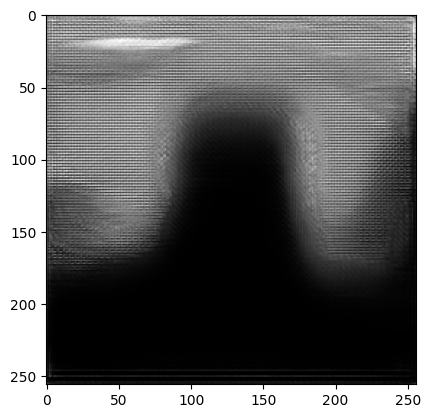

In [46]:
x = (out - out.min())/(out.max()-out.min())
x = x.permute(1,2,0)
plt.imshow(x,cmap='gray')

In [75]:
for name, module in D_model.named_modules():
    if isinstance(module, torch.nn.BatchNorm2d):
        print(name)

cnn_blocks.1.1
cnn_blocks.2.1
cnn_blocks.3.1
cnn_blocks.4.1
cnn_blocks.5.1
